
# Module 1 — Identity & Voice Capture


In [1]:

import os
import cv2
import numpy as np
import mediapipe as mp
import subprocess
import json
from pathlib import Path

# Audio analysis
import librosa
import soundfile as sf
import noisereduce as nr

print("OpenCV:", cv2.__version__)
print("MediaPipe:", mp.__version__)
print("All imports OK.")


OpenCV: 4.13.0
MediaPipe: 0.10.35
All imports OK.


In [2]:

# ── FIXED TIMING — the single source of truth for every cut made below ────────
# Change these two numbers if real recordings show different timing is needed.
# Every other cell in this notebook derives its cut points from these.

LIVENESS_WINDOW_SEC = 8     # Step 1: look forward, turn left, turn right
EMOTION_WINDOW_SEC = 7      # Steps 2-6: one sentence each

EMOTION_ORDER = ["normal", "loud", "happy", "angry", "sad"]

# Computed boundaries — do not edit these directly, they're derived from the two constants above.
SEGMENT_BOUNDARIES = {"liveness": (0, LIVENESS_WINDOW_SEC)}
cursor = LIVENESS_WINDOW_SEC
for tag in EMOTION_ORDER:
    SEGMENT_BOUNDARIES[tag] = (cursor, cursor + EMOTION_WINDOW_SEC)
    cursor += EMOTION_WINDOW_SEC

TOTAL_EXPECTED_DURATION_SEC = cursor

print("Fixed segment boundaries for this recording protocol:")
for tag, (start, end) in SEGMENT_BOUNDARIES.items():
    print(f"  [{tag:>9}]  {start:>4.0f}s → {end:>4.0f}s")
print(f"\nTotal expected recording length: {TOTAL_EXPECTED_DURATION_SEC:.0f} seconds")


Fixed segment boundaries for this recording protocol:
  [ liveness]     0s →    8s
  [   normal]     8s →   15s
  [     loud]    15s →   22s
  [    happy]    22s →   29s
  [    angry]    29s →   36s
  [      sad]    36s →   43s

Total expected recording length: 43 seconds


In [ ]:

# ── POINT THIS AT YOUR ONE TEST RECORDING ─────────────────────────────
# Record ONE continuous video following the steps in the table above, with your phone/webcam app
# (or a simple recording screen) showing each prompt for the fixed duration set above, back to back, the main file is record_test_video.py file
# no pauses or stops in between. Save it into test_videos/ and set the path below.

TEST_VIDEO_PATH = "test_videos/enrollment_session.mp4"   # <-- change this to your recorded file

if not os.path.exists(TEST_VIDEO_PATH):
    print(f"⚠️  No file found at '{TEST_VIDEO_PATH}'.")
    print("    This is expected if you haven't recorded a test video yet.")
    print(f"    Record one following the table above (~{TOTAL_EXPECTED_DURATION_SEC:.0f}s total),")
    print("    place it in test_videos/, and re-run this cell.")
else:
    cap = cv2.VideoCapture(TEST_VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frame_count / fps if fps else 0
    cap.release()
    print(f"✅ Found video: {TEST_VIDEO_PATH}")
    print(f"   Duration: {duration:.1f}s · FPS: {fps:.1f} · Frames: {frame_count}")
    print(f"   Expected: ~{TOTAL_EXPECTED_DURATION_SEC:.0f}s")
    if abs(duration - TOTAL_EXPECTED_DURATION_SEC) > 3:
        print(f"   ⚠️  Actual duration is more than 3s off from expected —")
        print(f"      double check the recording followed the fixed timing above.")


✅ Found video: test_videos/enrollment_session.mp4
   Duration: 45.1s · FPS: 29.9 · Frames: 1346
   Expected: ~43s



---
## 1. Sub-module 1A — Human Detection

This section does three things, in order:
1. Detect face landmarks in every frame
2. Compute a yaw angle (left/right rotation) per frame from those landmarks
3. Decide, from the sequence of yaw angles across the video, whether a genuine left-then-right turn happened



### 1.1 Face landmark detection + yaw angle per frame


In [ ]:

import urllib.request

MODEL_PATH = "face_landmarker.task"
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"

if not os.path.exists(MODEL_PATH):
    print("Downloading face_landmarker.task (one-time, ~3.7MB)...")
    try:
        urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
        print(f"✅ Downloaded to {MODEL_PATH}")
    except Exception as e:
        print(f"⚠️  Could not download automatically ({e}).")
        print(f"    Download it manually from:\n    {MODEL_URL}")
        print(f"    and place it as '{MODEL_PATH}' next to this notebook, then re-run this cell.")
else:
    print(f"✅ Model already present at {MODEL_PATH}")


✅ Model already present at face_landmarker.task


In [5]:

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

def create_face_landmarker(model_path=MODEL_PATH):
    '''Creates a MediaPipe FaceLandmarker configured for video (one frame at a time, IMAGE mode).'''
    base_options = mp_python.BaseOptions(model_asset_path=model_path)
    options = mp_vision.FaceLandmarkerOptions(
        base_options=base_options,
        running_mode=mp_vision.RunningMode.IMAGE,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        output_facial_transformation_matrixes=True,
    )
    return mp_vision.FaceLandmarker.create_from_options(options)


def yaw_from_transform_matrix(matrix):
    '''Extracts yaw (left/right rotation, degrees) from a 4x4 facial transformation matrix.'''
    # Rotation sub-matrix is the top-left 3x3 block
    r = matrix[:3, :3]
    sy = np.sqrt(r[0, 0] ** 2 + r[1, 0] ** 2)
    yaw = np.degrees(np.arctan2(-r[2, 0], sy))
    return yaw


def estimate_yaw_for_frame(frame, landmarker):
    '''Returns yaw angle in degrees for one BGR frame, or None if no face was detected.'''
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)

    if not result.facial_transformation_matrixes:
        return None

    matrix = np.array(result.facial_transformation_matrixes[0]).reshape(4, 4)
    return yaw_from_transform_matrix(matrix)


if os.path.exists(MODEL_PATH):
    print("FaceLandmarker helpers ready.")
else:
    print("⚠️  Model file not present yet — download it in the cell above before continuing.")


FaceLandmarker helpers ready.


In [6]:

def analyze_video_yaw(video_path, start_sec=0, end_sec=None, sample_every_n_frames=2):
    '''
    Runs yaw estimation across a TIME WINDOW of the video (not necessarily the whole file) and
    returns a list of (timestamp_sec, yaw_degrees). Used here to look only at the liveness portion
    (the first LIVENESS_WINDOW_SEC seconds) of the one shared recording.
    '''
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    start_frame = int(start_sec * fps)
    end_frame = int(end_sec * fps) if end_sec is not None else None

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    results = []

    landmarker = create_face_landmarker()
    try:
        frame_idx = start_frame
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if end_frame is not None and frame_idx >= end_frame:
                break
            if frame_idx % sample_every_n_frames == 0:
                yaw = estimate_yaw_for_frame(frame, landmarker)
                timestamp = frame_idx / fps
                results.append((timestamp, yaw))
            frame_idx += 1
    finally:
        landmarker.close()
        cap.release()
    return results


if os.path.exists(TEST_VIDEO_PATH) and os.path.exists(MODEL_PATH):
    liveness_start, liveness_end = SEGMENT_BOUNDARIES["liveness"]
    yaw_series = analyze_video_yaw(TEST_VIDEO_PATH, start_sec=liveness_start, end_sec=liveness_end)
    detected = [y for t, y in yaw_series if y is not None]
    print(f"Analyzing liveness window: {liveness_start:.0f}s → {liveness_end:.0f}s")
    print(f"Processed {len(yaw_series)} sampled frames.")
    print(f"Face detected in {len(detected)}/{len(yaw_series)} sampled frames.")
    if detected:
        print(f"Yaw range observed: {min(detected):.1f}° to {max(detected):.1f}°")
elif not os.path.exists(MODEL_PATH):
    yaw_series, detected = [], []
    print("Skipped — face_landmarker.task model not downloaded yet (see cell above).")
else:
    yaw_series, detected = [], []
    print("Skipped — no test video yet. Re-run Section 0 once you've recorded one.")


W0000 00:00:1782154113.217098   39448 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782154113.278627   39448 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782154113.280943   39476 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: AMD Ryzen 7 9700X 8-Core Processor (radeonsi, raphael_mendocino, LLVM 20.1.2, DRM 3.64, 6.17.0-35-generic)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782154113.282678   39455 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782154113.290403   39454 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Analyzing liveness window: 0s → 8s
Processed 119 sampled frames.
Face detected in 119/119 sampled frames.
Yaw range observed: -38.7° to 54.8°



### 1.2 Visualize the yaw curve

Plotting yaw-over-time is the fastest way to see whether the threshold logic below will actually work —
you should see roughly: near 0° (facing forward) → a swing to one side → back near 0° → a swing to the
other side → back near 0°. If the curve looks noisy or the face keeps dropping out, that is exactly the
kind of finding this notebook exists to surface before it becomes a production bug.


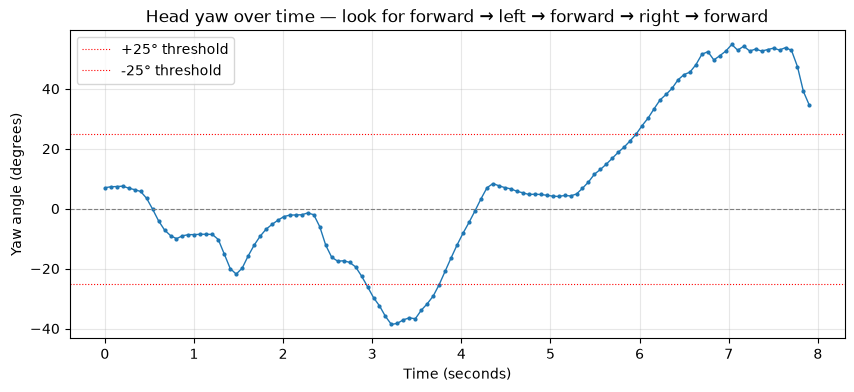

In [7]:

import matplotlib.pyplot as plt

if os.path.exists(TEST_VIDEO_PATH) and detected:
    times = [t for t, y in yaw_series if y is not None]
    yaws = [y for t, y in yaw_series if y is not None]

    plt.figure(figsize=(10, 4))
    plt.plot(times, yaws, marker='o', markersize=2, linewidth=1)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axhline(25, color='red', linestyle=':', linewidth=0.8, label='+25° threshold')
    plt.axhline(-25, color='red', linestyle=':', linewidth=0.8, label='-25° threshold')
    plt.xlabel("Time (seconds)")
    plt.ylabel("Yaw angle (degrees)")
    plt.title("Head yaw over time — look for forward → left → forward → right → forward")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Skipped — no data to plot yet.")



### 1.3 Decide pass/fail — did a genuine left-then-right turn happen?

This is the actual liveness decision for Sub-module 1A. The threshold (±25°) is a starting point from
the R&D plan, not a final answer — **this is exactly the number to tune once you have a few real test
recordings**, watching whether genuine attempts pass comfortably and whether a deliberately lazy
"barely-there" turn correctly fails.


In [8]:

YAW_THRESHOLD_DEGREES = 25.0

def check_left_right_turn(yaw_series, threshold=YAW_THRESHOLD_DEGREES):
    '''
    Returns a result dict describing whether a left-then-right (or right-then-left) turn
    was detected, plus the diagnostic values behind the decision.
    '''
    yaws = [y for t, y in yaw_series if y is not None]
    detection_rate = len(yaws) / len(yaw_series) if yaw_series else 0

    if detection_rate < 0.5:
        return {
            "result": "fail",
            "reason": "face_not_consistently_detected",
            "detection_rate": round(detection_rate, 2),
        }

    max_left = float(min(yaws))   # most negative
    max_right = float(max(yaws))  # most positive

    turned_left = bool(max_left <= -threshold)
    turned_right = bool(max_right >= threshold)

    if turned_left and turned_right:
        return {
            "result": "pass",
            "reason": None,
            "max_left_deg": round(max_left, 1),
            "max_right_deg": round(max_right, 1),
            "detection_rate": round(detection_rate, 2),
        }
    else:
        return {
            "result": "fail",
            "reason": "insufficient_turn_range",
            "max_left_deg": round(max_left, 1),
            "max_right_deg": round(max_right, 1),
            "detection_rate": round(detection_rate, 2),
        }


if os.path.exists(TEST_VIDEO_PATH):
    sub1a_result = check_left_right_turn(yaw_series)
    print(json.dumps(sub1a_result, indent=2))
else:
    sub1a_result = None
    print("Skipped — no test video yet.")


{
  "result": "pass",
  "reason": null,
  "max_left_deg": -38.7,
  "max_right_deg": 54.8,
  "detection_rate": 1.0
}



---
## 2.Voice Collection



### 2.1 Cut and process each fixed-position emotion window

For each of the 5 emotion windows: cut that time range out of the one shared video's audio, reduce
background noise, and run a quality check. No detection step is needed — the start/end seconds for
every window come directly from `SEGMENT_BOUNDARIES`, computed once in Section 0.


In [9]:

def extract_audio_range(video_path, output_path, start_sec, end_sec):
    '''
    Extracts a TIME RANGE of the audio track from a video file as 16-bit PCM WAV, using FFmpeg's
    -ss (start) and -to (end) options. This is how every fixed-position segment is cut from the
    one shared recording — no detection involved, just a direct time-range cut.
    '''
    cmd = [
        "ffmpeg", "-y", "-i", video_path,
        "-ss", str(start_sec), "-to", str(end_sec),
        "-vn", "-acodec", "pcm_s16le", "-ar", "16000", "-ac", "1",
        output_path
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("FFmpeg error:")
        print(result.stderr[-800:])
        return False
    return True


def reduce_noise(y, sr, noise_sample_duration=0.5):
    '''
    Reduces background noise using spectral gating. Uses the first `noise_sample_duration`
    seconds of THIS segment as the noise profile. Each segment is cleaned independently, since
    background conditions are the same throughout one continuous recording anyway.
    '''
    noise_sample_len = int(noise_sample_duration * sr)
    noise_clip = y[:noise_sample_len] if len(y) > noise_sample_len else y
    cleaned = nr.reduce_noise(y=y, sr=sr, y_noise=noise_clip, stationary=True)
    return cleaned


print("Helper functions ready.")


Helper functions ready.



### 2.2 Quality check each clip

Mirrors Module 2's `M2.2 — Quality check` milestone: each clip needs to be long enough, loud enough,
and actually contain speech. A clip failing this check only requires that **one** emotion to be
re-recorded — every other clip is unaffected.


In [10]:

MIN_DURATION_SEC = 0.8
MIN_RMS_LOUDNESS = 0.01   # starting point — tune against real quiet/loud recordings
SILENCE_CHECK_TOP_DB = 30  # used only to confirm speech exists at all within this one clip


def contains_speech(y, sr, top_db=SILENCE_CHECK_TOP_DB):
    '''Checks whether at least one non-silent region exists in this (already isolated) clip.'''
    intervals = librosa.effects.split(y, top_db=top_db)
    return len(intervals) > 0


def quality_check_clip(y, sr, emotion_tag):
    duration_sec = len(y) / sr
    duration_ok = bool(duration_sec >= MIN_DURATION_SEC)
    rms = float(np.sqrt(np.mean(y.astype(np.float64) ** 2)))
    loudness_ok = bool(rms >= MIN_RMS_LOUDNESS)
    speech_ok = bool(contains_speech(y, sr))

    passed = duration_ok and loudness_ok and speech_ok
    return {
        "emotion_tag": emotion_tag,
        "result": "pass" if passed else "fail",
        "duration_sec": round(duration_sec, 2),
        "duration_ok": duration_ok,
        "rms_loudness": round(rms, 4),
        "loudness_ok": loudness_ok,
        "contains_speech": speech_ok,
    }


print("Quality check ready.")


Quality check ready.



### 2.3 Run the pipeline across all 5 fixed-position windows

This is the main loop: for each emotion, in order, cut its fixed time-range out of the one shared
recording → denoise → quality-check, and keep the cleaned audio in memory for the next section.


In [11]:

emotion_clips = {}   # emotion_tag -> {"audio": np.array, "sr": int, "quality": {...}}
os.makedirs("output", exist_ok=True)

if os.path.exists(TEST_VIDEO_PATH):
    for emotion_tag in EMOTION_ORDER:
        start_sec, end_sec = SEGMENT_BOUNDARIES[emotion_tag]

        raw_audio_path = f"output/{emotion_tag}_raw.wav"
        ok = extract_audio_range(TEST_VIDEO_PATH, raw_audio_path, start_sec, end_sec)
        if not ok:
            print(f"❌ [{emotion_tag:>6}]  Audio extraction failed for window {start_sec}-{end_sec}s.")
            continue

        y, sr = librosa.load(raw_audio_path, sr=None)
        y_clean = reduce_noise(y, sr)

        clean_audio_path = f"output/{emotion_tag}_clean.wav"
        sf.write(clean_audio_path, y_clean, sr)

        quality = quality_check_clip(y_clean, sr, emotion_tag)
        emotion_clips[emotion_tag] = {"audio": y_clean, "sr": sr, "quality": quality}

        status = "✅" if quality["result"] == "pass" else "❌"
        print(f"{status} [{emotion_tag:>6}]  window={start_sec:.0f}-{end_sec:.0f}s  "
              f"duration={quality['duration_sec']}s  rms={quality['rms_loudness']}  "
              f"speech={quality['contains_speech']}")
else:
    print("Skipped — no test video yet.")

if os.path.exists(TEST_VIDEO_PATH) and not emotion_clips:
    print()
    print("No segments processed — check that the video covers the full expected duration.")


✅ [normal]  window=8-15s  duration=7.0s  rms=0.035  speech=True
✅ [  loud]  window=15-22s  duration=7.0s  rms=0.0306  speech=True
✅ [ happy]  window=22-29s  duration=7.0s  rms=0.0171  speech=True
✅ [ angry]  window=29-36s  duration=7.0s  rms=0.0277  speech=True
✅ [   sad]  window=36-43s  duration=7.0s  rms=0.0261  speech=True


In [12]:
for tag, data in emotion_clips.items():
    print(f"[{tag:>6}]  rms = {data['quality']['rms_loudness']}")

[normal]  rms = 0.035
[  loud]  rms = 0.0306
[ happy]  rms = 0.0171
[ angry]  rms = 0.0277
[   sad]  rms = 0.0261



### 2.4 Visualize all 5 cleaned clips together

A quick side-by-side view of the 5 waveforms — useful for spotting at a glance whether the relative
energy/intensity differences between emotions look like what you'd expect (e.g. "angry" and "loud"
visibly more intense than "sad").


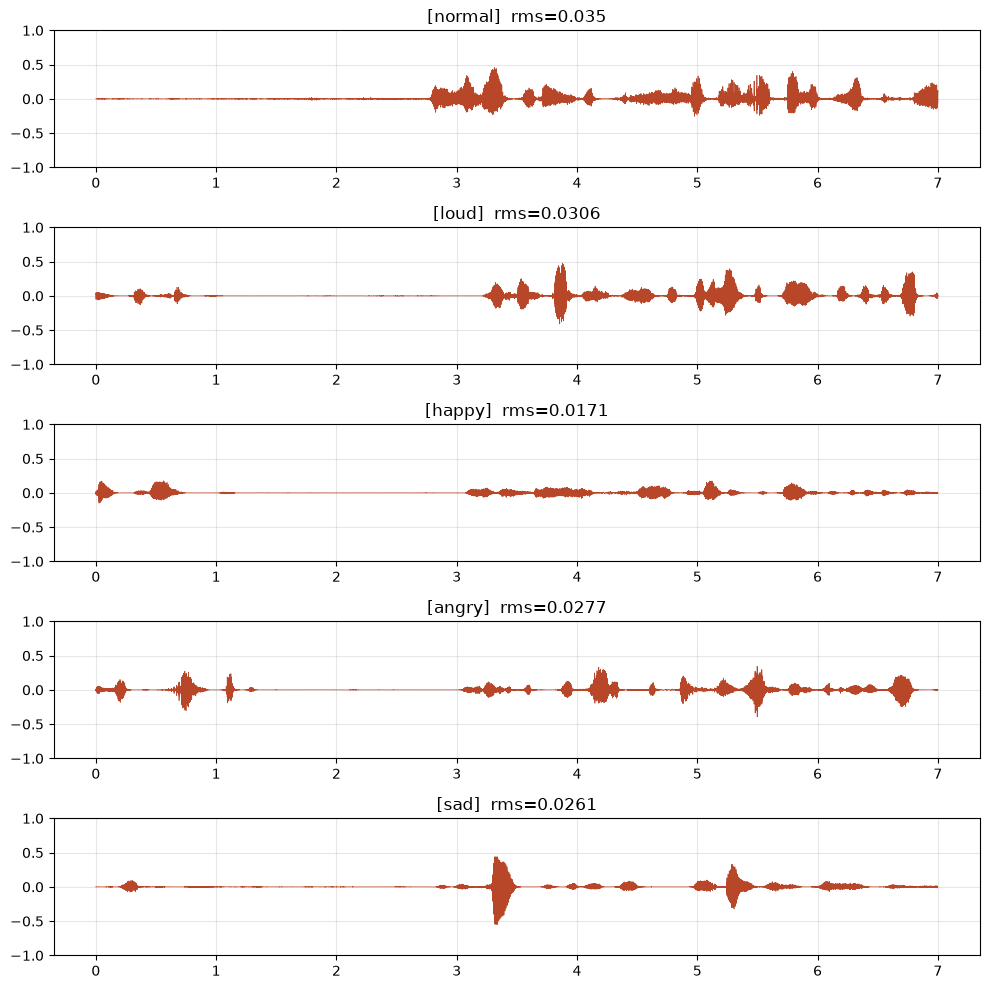

In [13]:

if emotion_clips:
    fig, axes = plt.subplots(len(emotion_clips), 1, figsize=(10, 2 * len(emotion_clips)), sharex=False)
    if len(emotion_clips) == 1:
        axes = [axes]

    for ax, (tag, data) in zip(axes, emotion_clips.items()):
        y, sr = data["audio"], data["sr"]
        times = np.linspace(0, len(y) / sr, num=len(y))
        ax.plot(times, y, linewidth=0.5, color="#B8472A")
        ax.set_title(f"[{tag}]  rms={data['quality']['rms_loudness']}")
        ax.set_ylim(-1, 1)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Skipped — no clips to plot yet.")



---
## 3. Choosing the Emotion Anchors for Module 2

Per the Emotional Voice Generation design, Module 2's cloning model only needs **two** reference
points to generate the full emotional range later: a **calm baseline** and an **expressive peak**.
We've now recorded 5 clips — this section decides which ones feed Module 2 as those two anchors, and
what happens to the rest.

**The decision applied here:**
- `normal` is always the **calm baseline** — it's the one delivery explicitly recorded without any
  emotional performance, so it's the most reliable neutral reference.
- The **expressive peak** is chosen automatically from the remaining four (`loud`, `happy`, `angry`,
  `sad`) by picking whichever has the highest energy (RMS loudness) — a simple, defensible proxy for
  "most expressive" without needing a more complex model just to make this choice.

In [14]:

def select_anchors(emotion_clips):
    if "normal" not in emotion_clips:
        print("⚠️  No 'normal' clip available — cannot select a calm baseline anchor.")
        return None

    calm_baseline = emotion_clips["normal"]

    candidates = {tag: data for tag, data in emotion_clips.items() if tag != "normal"}
    if not candidates:
        print("⚠️  No non-normal clips available — cannot select an expressive peak anchor.")
        return None

    peak_tag = max(candidates, key=lambda t: candidates[t]["quality"]["rms_loudness"])
    expressive_peak = candidates[peak_tag]

    validation_tags = [t for t in candidates if t != peak_tag]

    return {
        "calm_baseline_tag": "normal",
        "calm_baseline_rms": calm_baseline["quality"]["rms_loudness"],
        "expressive_peak_tag": peak_tag,
        "expressive_peak_rms": expressive_peak["quality"]["rms_loudness"],
        "validation_clip_tags": validation_tags,
    }


if emotion_clips:
    anchor_selection = select_anchors(emotion_clips)
    if anchor_selection:
        print(json.dumps(anchor_selection, indent=2))
else:
    anchor_selection = None
    print("Skipped — no emotion clips processed yet.")


{
  "calm_baseline_tag": "normal",
  "calm_baseline_rms": 0.035,
  "expressive_peak_tag": "loud",
  "expressive_peak_rms": 0.0306,
  "validation_clip_tags": [
    "happy",
    "angry",
    "sad"
  ]
}



> **R&D note** Picking the expressive peak purely by loudness (RMS) is a reasonable
> starting point, but loudness alone doesn't fully capture "expressiveness" — a clip could be loud but
> monotone, or moderately quiet but full of pitch variation (which often reads as more emotionally rich
> than volume alone). A natural follow-up R&D task is testing whether adding pitch-variance as a second
> signal produces a better choice of peak anchor than loudness alone — worth comparing once a few real
> users' recordings are available.
